# Analisi Statistica: Wilcoxon Signed-Rank Test
In questo notebook analizziamo se il **gap** tra i flussi migratori registrati da **Eurostat** e quelli registrati da **ISTAT** è sistematicamente diverso da zero.

A differenza del test del Chi Quadrato (che valuta la distribuzione temporale), il test di Wilcoxon valuta se una delle due fonti tende a sottostimare o sovrastimare i flussi rispetto all'altra in modo consistente.

**Ipotesi Nulla ($H_0$):** La mediana delle differenze tra Eurostat e ISTAT è zero (non c'è un bias sistematico).
**Ipotesi Alternativa ($H_1$):** La mediana delle differenze è diversa da zero (esiste un bias sistematico).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from wilcoxon_test import MigrationWilcoxonTest
import make_dataset
import math

# Rigenerazione del dataset dai dati grezzi (data/raw/)
make_dataset.main()

# Inizializzazione suite
tester = MigrationWilcoxonTest("../data/merged_migration_data.csv")

# Caricamento risultati riassuntivi
summary_df = tester.get_summary_df()
summary_df

Scanning raw data in c:\Users\FeN30\Desktop\report\data\raw...
Successfully merged 40 records into c:\Users\FeN30\Desktop\report\data\merged_migration_data.csv


,Test,N,Gap mediano,W stat,p-value,Rifiuta H0 (a=0.05),Rifiuta H0 (a=0.01),Rifiuta H0 (a=0.001)
0,GLOBAL (tutte le coppie),40,918.5,34.0,4.300000e-07,Si',Si',Si'
1,PER-COUNTRY (totali 5 anni),8,4565.5,0.0,7.812500e-03,Si',Si',No


### Interpretazione dei Risultati ($W$ stat)
La statistica $W$ restituita dal test di Wilcoxon rappresenta il **valore minimo** tra la somma dei ranghi positivi e quella dei ranghi negativi. 

- **Test Global ($N=40$):** Con 40 osservazioni, la somma totale dei ranghi è 820. Sotto l'ipotesi nulla (nessun bias), ci aspetteremmo $W \approx 410$. Un valore di **34.0** è estremamente basso e indica che in quasi tutte le coppie Eurostat registra valori superiori a ISTAT ($Z \approx 5.05$).
- **Test Per-Country ($N=8$):** Un valore di **0.0** indica che, aggregando i dati sui 5 anni, **in tutti gli 8 paesi analizzati** il totale Eurostat è superiore al totale ISTAT. Non essendoci nemmeno un'eccezione, la somma dei ranghi della minoranza è esattamente zero.

Questi risultati confermano con estrema robustezza statistica ($p < 0.001$ nel caso globale) che esiste un **bias sistematico di sottostima** nei dati ISTAT rispetto ai paesi di destinazione.

## Verifica della Normalità (Shapiro-Wilk)
Il test di Wilcoxon è un test non parametrico, ideale quando i dati non seguono una distribuzione normale. Verifichiamo questa assunzione sui gap calcolati.

**Statistica W:** Rappresenta la forza della correlazione tra i dati osservati e i quantili teorici di una distribuzione normale. 
- Valori di **W vicini a 1** indicano che i dati sono probabilmente normali.
- Valori di **W significativamente inferiori a 1** (accompagnati da un p-value < 0.05) indicano che i dati NON seguono una distribuzione normale.

In [2]:
normality_results = tester.test_normality()
print(f"Test di Shapiro-Wilk: W={normality_results['stat']}, p-value={normality_results['p_value']:.10f}")
print(f"Interpretazione: {normality_results['interpretation']}")

Test di Shapiro-Wilk: W=0.5978, p-value=0.0000000029
Interpretazione: I gap NON sono normali (p < 0.05) -> Wilcoxon e' la scelta corretta


## Visualizzazione del Gap per Paese
Visualizziamo la distribuzione dei gap (Eurostat - ISTAT) per ogni paese attraverso dei boxplot, per evidenziare la variabilità e la presenza di bias sistematici.

C:\Users\FeN30\AppData\Local\Temp\ipykernel_2680\2265922183.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=countries, patch_artist=True,


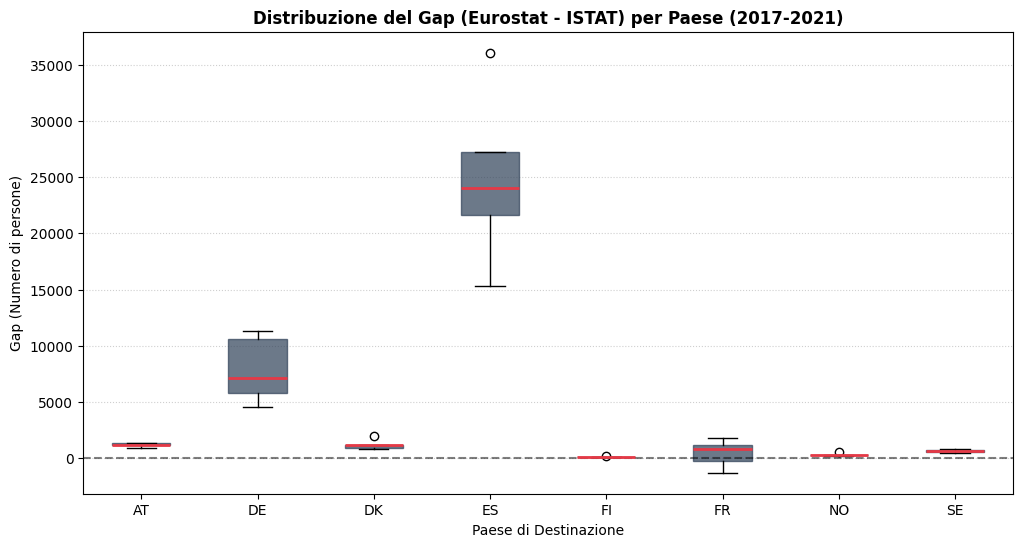

In [3]:
df = tester.df.copy()
countries = sorted(df['DESTINATION_STATE'].unique())
data_to_plot = [df[df['DESTINATION_STATE'] == c]['GAP'] for c in countries]

plt.figure(figsize=(12, 6))
plt.boxplot(data_to_plot, labels=countries, patch_artist=True, 
            boxprops=dict(facecolor='#2e4057', color='#2e4057', alpha=0.7),
            medianprops=dict(color='#e63946', linewidth=2))

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Distribuzione del Gap (Eurostat - ISTAT) per Paese (2017-2021)", fontweight='bold')
plt.ylabel("Gap (Numero di persone)")
plt.xlabel("Paese di Destinazione")
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

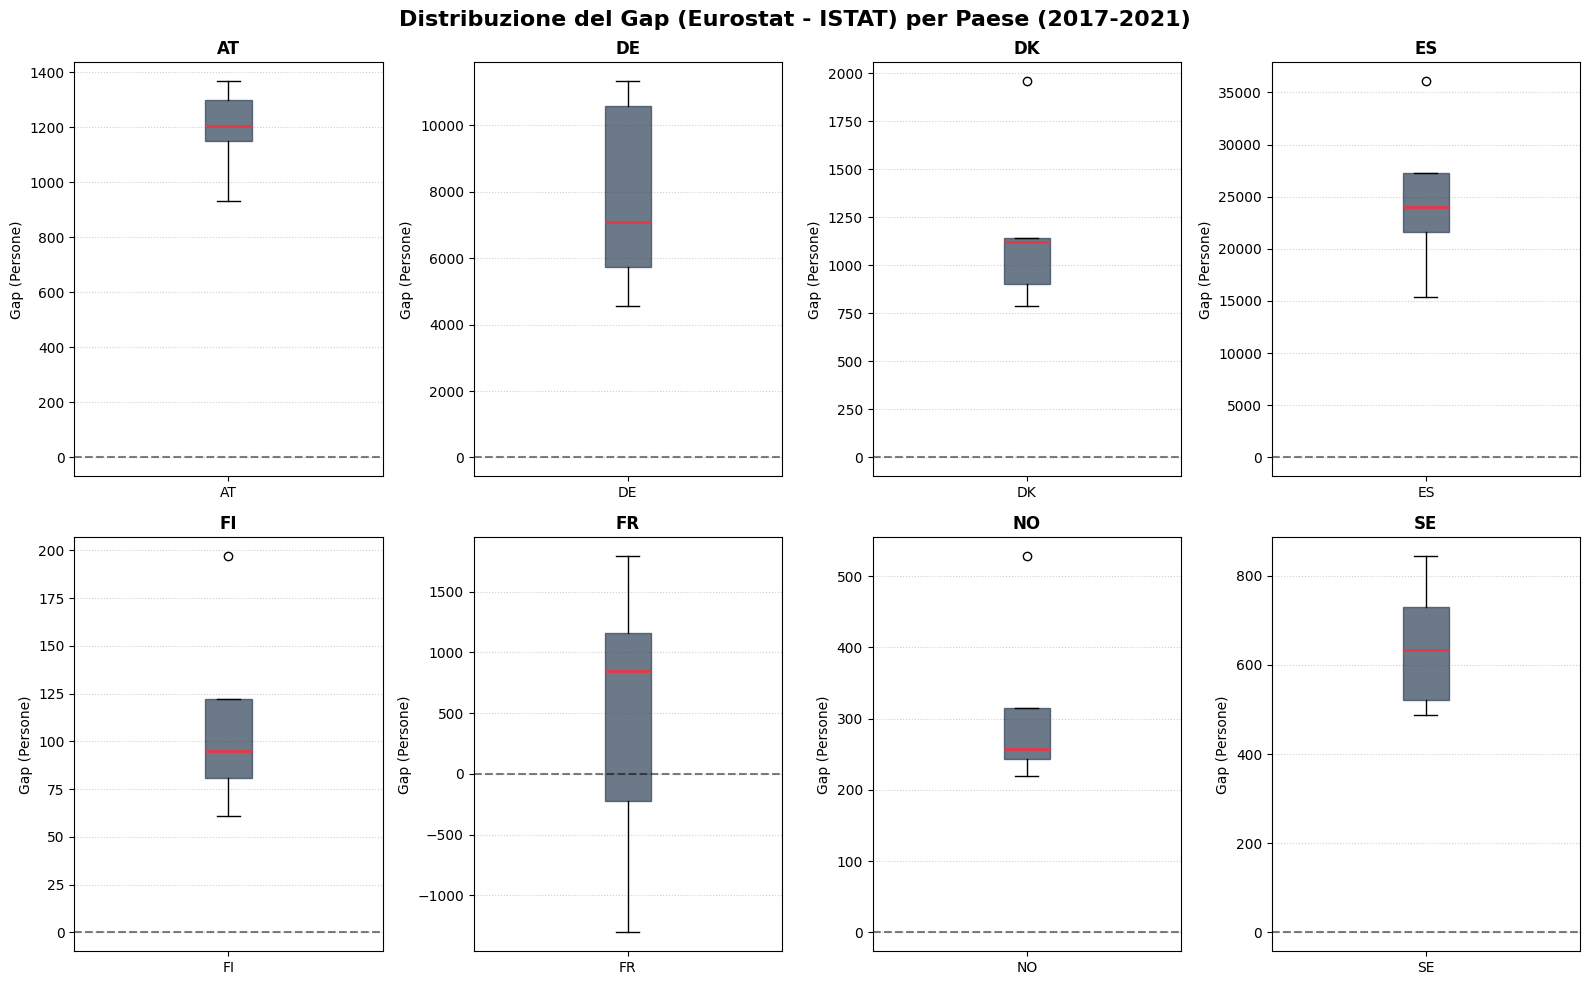

In [5]:
# Definisci il numero di colonne desiderato per la griglia
cols = 4 
# Calcola dinamicamente il numero di righe necessarie
rows = math.ceil(len(countries) / cols)

# Crea la griglia di grafici
fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 5))

# Appiattisci l'array degli assi per iterare facilmente
# (Nel caso ci sia un solo grafico, lo mettiamo in una lista per evitare errori)
axes = np.array(axes).flatten() if len(countries) > 1 else [axes]

for i, country in enumerate(countries):
    ax = axes[i]
    # Estrai i dati per il paese specifico (rimuovendo eventuali NaN per evitare errori nel boxplot)
    data = df[df['DESTINATION_STATE'] == country]['GAP'].dropna()
    
    # Crea il boxplot sul subplot corrente (ax)
    ax.boxplot(data, tick_labels=[country], patch_artist=True, 
               boxprops=dict(facecolor='#2e4057', color='#2e4057', alpha=0.7),
               medianprops=dict(color='#e63946', linewidth=2))
    
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_title(country, fontweight='bold')
    ax.set_ylabel("Gap (Persone)")
    ax.grid(axis='y', linestyle=':', alpha=0.6)

# Se il numero di paesi non riempie completamente la griglia, nascondi gli assi vuoti rimanenti
for j in range(len(countries), len(axes)):
    fig.delaxes(axes[j])

# Aggiungi un titolo generale e ottimizza gli spazi
plt.suptitle("Distribuzione del Gap (Eurostat - ISTAT) per Paese (2017-2021)", fontweight='bold', fontsize=16)
plt.tight_layout()
plt.show()